# EDA: IEEE-CIS Fraud Detection

Load raw data via `io_utils`, explore class distribution, TransactionAmt, missingness, and TransactionDT.

In [1]:
import sys
from pathlib import Path
# Project root (run from repo root or notebooks/)
ROOT = Path.cwd() if (Path.cwd() / "main.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import os; os.chdir(ROOT)

from src.config import Config
from src.io_utils import discover_files, load_raw_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
config = Config()
files = discover_files(config.raw_data_dir)
print("Discovered files:", {k: str(v) for k, v in files.items() if v})
raw = load_raw_data(config.raw_data_dir)
train = raw["train_transaction"]
if raw.get("train_identity") is not None:
    train = train.merge(raw["train_identity"], on="TransactionID", how="left")

Discovered files: {'train_transaction': '/Users/dhwanil/Desktop/ONGOING PROJECTS/Real Time Fraud Detection/data/raw/train_transaction.csv', 'train_identity': '/Users/dhwanil/Desktop/ONGOING PROJECTS/Real Time Fraud Detection/data/raw/train_identity.csv', 'test_transaction': '/Users/dhwanil/Desktop/ONGOING PROJECTS/Real Time Fraud Detection/data/raw/test_transaction.csv', 'test_identity': '/Users/dhwanil/Desktop/ONGOING PROJECTS/Real Time Fraud Detection/data/raw/test_identity.csv'}


Class distribution: isFraud
0    569877
1     20663
Name: count, dtype: int64


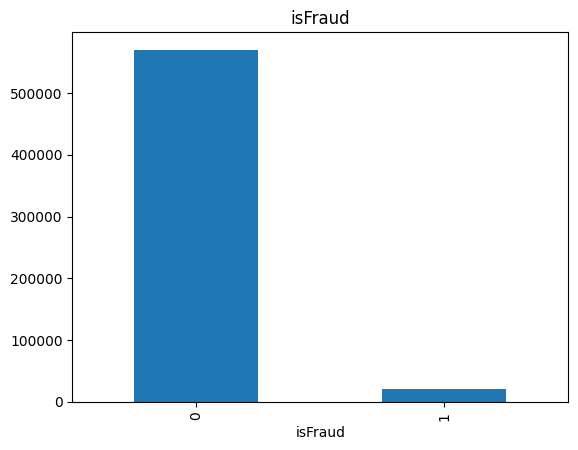

In [3]:
if "isFraud" in train.columns:
    print("Class distribution:", train["isFraud"].value_counts())
    train["isFraud"].value_counts().plot(kind="bar", title="isFraud")
    plt.show()

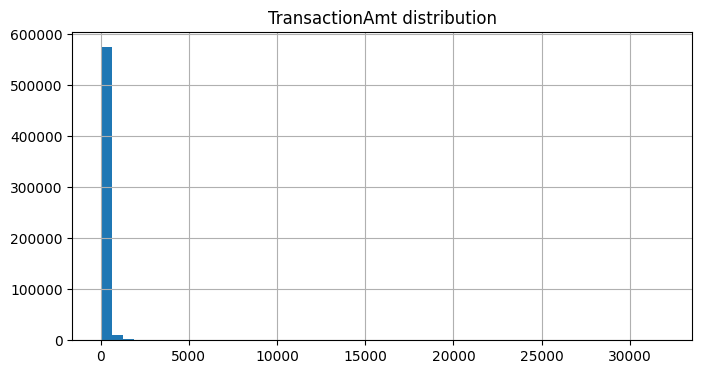

In [4]:
if "TransactionAmt" in train.columns:
    train["TransactionAmt"].hist(bins=50, figsize=(8, 4))
    plt.title("TransactionAmt distribution")
    plt.show()

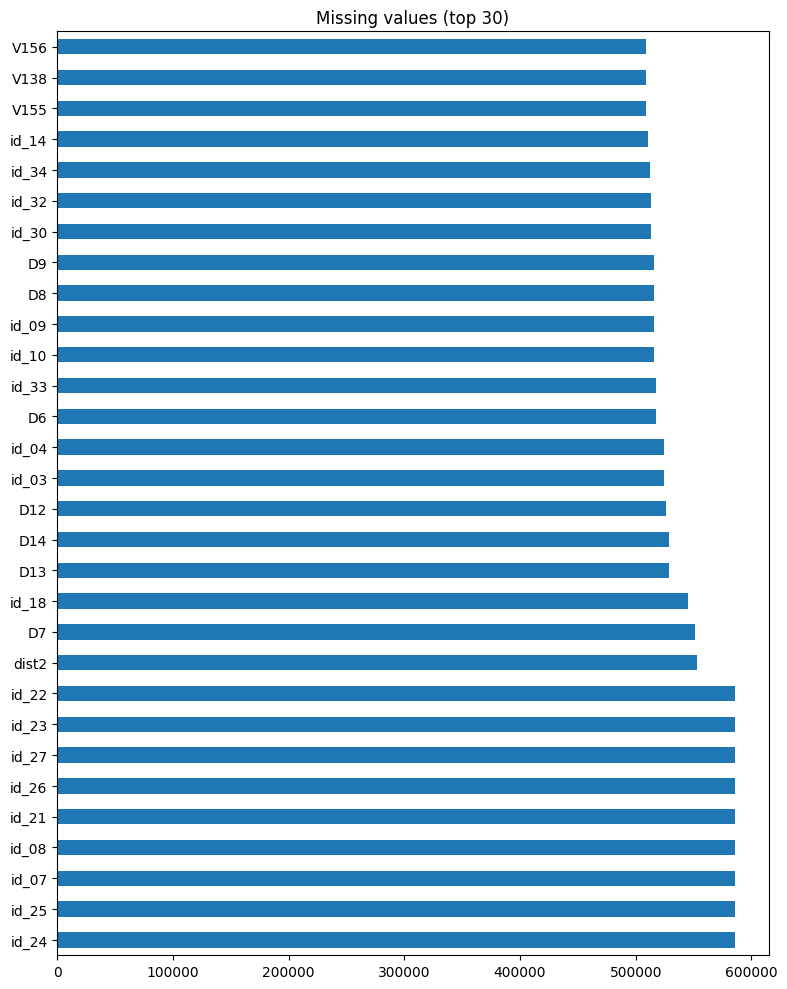

In [5]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(30)
if len(missing) > 0:
    missing.plot(kind="barh", figsize=(8, 10))
    plt.title("Missing values (top 30)")
    plt.tight_layout()
    plt.show()

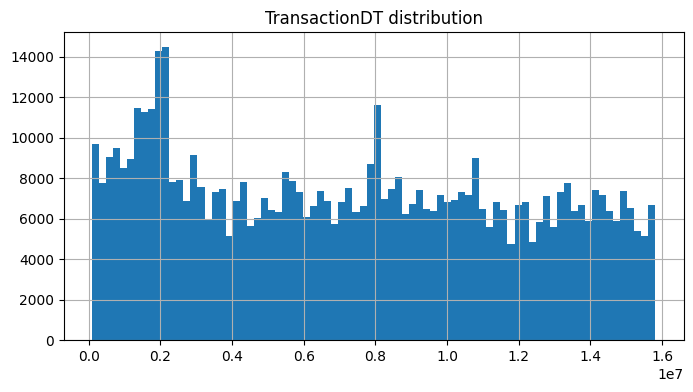

In [6]:
if "TransactionDT" in train.columns:
    train["TransactionDT"].hist(bins=80, figsize=(8, 4))
    plt.title("TransactionDT distribution")
    plt.show()